In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

TRADING_DAYS = 252
RISK_FREE_RATE = 0.065  # annualized, adjust to your actual T-bill rate source

In [3]:
# ---- Load fund NAV ----
nav = pd.read_csv('../data/processed/nav_history_clean.csv', parse_dates=['date'])

FUND_CODE = 119551  # SBI Bluechip Fund - Regular Plan - Growth
fund_nav = nav[nav['amfi_code'] == FUND_CODE][['date', 'nav']].copy()
fund_nav = fund_nav.sort_values('date').reset_index(drop=True)

# ---- Load benchmark (Nifty 100) ----
benchmark = pd.read_csv('../data/raw/10_benchmark_indices.csv', parse_dates=['date'])
nifty100 = benchmark[benchmark['index_name'] == 'NIFTY100'][['date', 'close_value']].copy()
nifty100 = nifty100.sort_values('date').reset_index(drop=True)
nifty100.rename(columns={'close_value': 'benchmark_price'}, inplace=True)

# ---- Merge on date (inner join keeps only overlapping trading days) ----
df = pd.merge(fund_nav, nifty100, on='date', how='inner')
df.rename(columns={'nav': 'fund_nav'}, inplace=True)
df = df.sort_values('date').reset_index(drop=True)

print(f"Rows after merge: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.head()

Rows after merge: 1150
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


,date,fund_nav,benchmark_price
0,2022-01-03,54.3856,17778.24
1,2022-01-04,54.3474,17537.52
2,2022-01-05,54.6869,17607.73
3,2022-01-06,55.4550,17556.05
4,2022-01-07,55.3692,17664.02


In [4]:
# ---- Daily returns ----
df['fund_ret'] = df['fund_nav'].pct_change()
df['benchmark_ret'] = df['benchmark_price'].pct_change()

# Drop the first row (NaN return) for return-based calcs
returns_df = df.dropna(subset=['fund_ret', 'benchmark_ret']).reset_index(drop=True)

# ---- CAGR ----
start_nav = df['fund_nav'].iloc[0]
end_nav = df['fund_nav'].iloc[-1]
start_date = df['date'].iloc[0]
end_date = df['date'].iloc[-1]
n_days = (end_date - start_date).days
n_years = n_days / 365.25

fund_cagr = (end_nav / start_nav) ** (1 / n_years) - 1

start_bm = df['benchmark_price'].iloc[0]
end_bm = df['benchmark_price'].iloc[-1]
benchmark_cagr = (end_bm / start_bm) ** (1 / n_years) - 1

print(f"Period: {n_years:.2f} years ({start_date.date()} to {end_date.date()})")
print(f"Fund CAGR: {fund_cagr:.4%}")
print(f"Benchmark (Nifty 100) CAGR: {benchmark_cagr:.4%}")

# ---- Annualized return (geometric, from daily returns — cross-check vs CAGR) ----
fund_ann_ret = (1 + returns_df['fund_ret']).prod() ** (TRADING_DAYS / len(returns_df)) - 1
benchmark_ann_ret = (1 + returns_df['benchmark_ret']).prod() ** (TRADING_DAYS / len(returns_df)) - 1

print(f"\nFund Annualized Return (from daily): {fund_ann_ret:.4%}")
print(f"Benchmark Annualized Return (from daily): {benchmark_ann_ret:.4%}")

Period: 4.40 years (2022-01-03 to 2026-05-29)
Fund CAGR: 25.8047%
Benchmark (Nifty 100) CAGR: 2.3560%

Fund Annualized Return (from daily): 24.7966%
Benchmark Annualized Return (from daily): 2.2725%


In [5]:
# ---- Sharpe Ratio ----
daily_rf = RISK_FREE_RATE / TRADING_DAYS  # convert annual risk-free rate to daily

returns_df['fund_excess_ret'] = returns_df['fund_ret'] - daily_rf

fund_sharpe = (returns_df['fund_excess_ret'].mean() / returns_df['fund_excess_ret'].std()) * np.sqrt(TRADING_DAYS)

print(f"Daily Risk-Free Rate: {daily_rf:.6%}")
print(f"Fund Sharpe Ratio: {fund_sharpe:.4f}")

Daily Risk-Free Rate: 0.025794%
Fund Sharpe Ratio: 1.2083


In [6]:
# ---- Sortino Ratio ----
downside_ret = returns_df['fund_excess_ret'][returns_df['fund_excess_ret'] < 0]
downside_std = np.sqrt((downside_ret ** 2).mean())

fund_sortino = (returns_df['fund_excess_ret'].mean() / downside_std) * np.sqrt(TRADING_DAYS)

print(f"Downside Deviation (annualized): {downside_std * np.sqrt(TRADING_DAYS):.4%}")
print(f"Fund Sortino Ratio: {fund_sortino:.4f}")


Downside Deviation (annualized): 13.1613%
Fund Sortino Ratio: 1.2615


In [7]:
perf = pd.read_csv('../data/processed/scheme_performance_clean.csv')
check = perf[perf['amfi_code'] == FUND_CODE][['scheme_name', 'sharpe_ratio', 'sortino_ratio', 'alpha', 'beta', 'max_drawdown_pct']]
print(check.to_string())

                                 scheme_name  sharpe_ratio  sortino_ratio  alpha  beta  max_drawdown_pct
0  SBI Bluechip Fund - Regular Plan - Growth          0.88           1.29   0.87  0.89             -21.7


In [8]:
# ---- Alpha / Beta via OLS regression ----
returns_df['benchmark_excess_ret'] = returns_df['benchmark_ret'] - daily_rf

X = returns_df['benchmark_excess_ret']
y = returns_df['fund_excess_ret']

X_const = sm.add_constant(X)  # adds intercept term (alpha)
model = sm.OLS(y, X_const).fit()

alpha_daily = model.params['const']
beta = model.params['benchmark_excess_ret']
alpha_annualized = alpha_daily * TRADING_DAYS

print(model.summary())
print(f"\nDaily Alpha: {alpha_daily:.6f}")
print(f"Annualized Alpha: {alpha_annualized:.4%}")
print(f"Beta: {beta:.4f}")
print(f"R-squared: {model.rsquared:.4f}")

                            OLS Regression Results                            
Dep. Variable:        fund_excess_ret   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.018
Date:                Thu, 13 Aug 2026   Prob (F-statistic):              0.313
Time:                        12:24:16   Log-Likelihood:                 3827.8
No. Observations:                1149   AIC:                            -7652.
Df Residuals:                    1147   BIC:                            -7641.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0007 

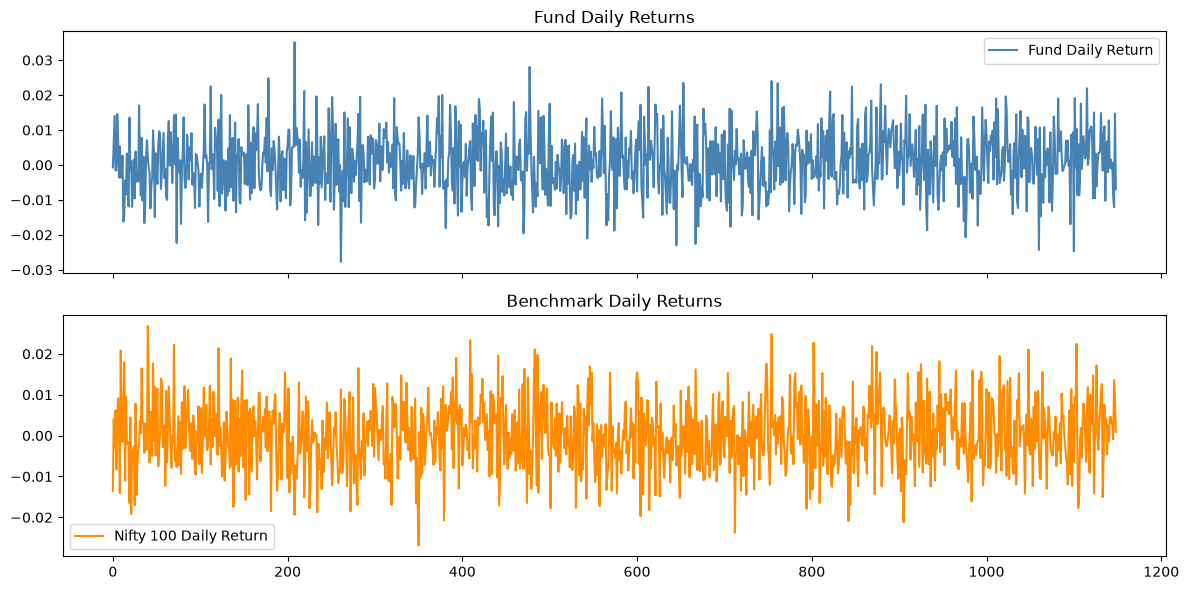

          fund_ret  benchmark_ret
count  1149.000000    1149.000000
mean      0.000917       0.000122
std       0.008656       0.008119
min      -0.027680      -0.026873
25%      -0.004866      -0.005385
50%       0.000940      -0.000112
75%       0.006442       0.005456
max       0.035096       0.026795

Correlation: -0.02978219078463307


In [9]:
# ---- Diagnostic: eyeball the two return series ----
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(returns_df['fund_ret'].values, label='Fund Daily Return', color='steelblue')
axes[0].legend(); axes[0].set_title('Fund Daily Returns')

axes[1].plot(returns_df['benchmark_ret'].values, label='Nifty 100 Daily Return', color='darkorange')
axes[1].legend(); axes[1].set_title('Benchmark Daily Returns')

plt.tight_layout()
plt.show()

print(returns_df[['fund_ret', 'benchmark_ret']].describe())
print("\nCorrelation:", returns_df['fund_ret'].corr(returns_df['benchmark_ret']))

Max Drawdown: -15.0124%
Peak Date: 2023-08-24
Trough Date: 2024-02-05
Recovery Date: 2025-01-08


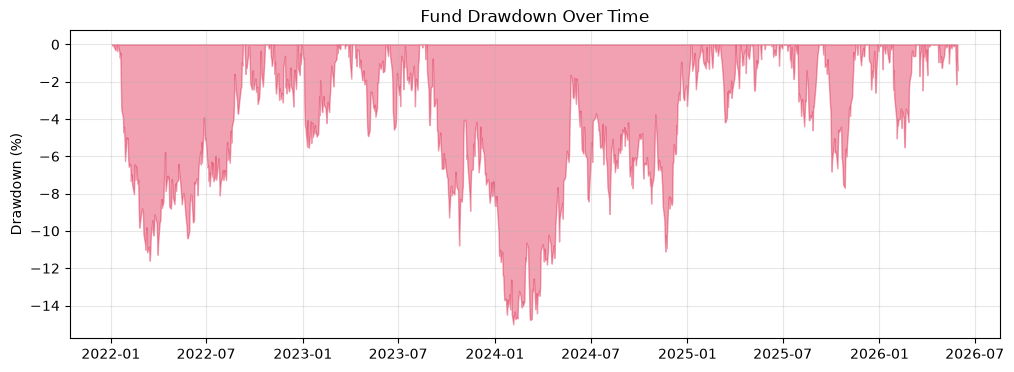

In [10]:
# ---- Max Drawdown ----
df['cum_ret'] = (1 + df['fund_nav'].pct_change().fillna(0)).cumprod()
df['running_max'] = df['cum_ret'].cummax()
df['drawdown'] = (df['cum_ret'] - df['running_max']) / df['running_max']

max_drawdown = df['drawdown'].min()
max_dd_date = df.loc[df['drawdown'].idxmin(), 'date']

# Find the peak before the trough, and recovery date after
trough_idx = df['drawdown'].idxmin()
peak_idx = df.loc[:trough_idx, 'cum_ret'].idxmax()
peak_date = df.loc[peak_idx, 'date']

recovery = df.loc[trough_idx:][df.loc[trough_idx:, 'cum_ret'] >= df.loc[peak_idx, 'cum_ret']]
recovery_date = recovery['date'].iloc[0] if len(recovery) > 0 else None

print(f"Max Drawdown: {max_drawdown:.4%}")
print(f"Peak Date: {peak_date.date()}")
print(f"Trough Date: {max_dd_date.date()}")
print(f"Recovery Date: {recovery_date.date() if recovery_date is not None else 'Not yet recovered'}")

# Plot drawdown
plt.figure(figsize=(12, 4))
plt.fill_between(df['date'], df['drawdown'] * 100, 0, color='crimson', alpha=0.4)
plt.title('Fund Drawdown Over Time')
plt.ylabel('Drawdown (%)')
plt.grid(alpha=0.3)
plt.show()

Tracking Error & Information Ratio

In [11]:
# ---- Tracking Error & Information Ratio ----
active_ret = returns_df['fund_ret'] - returns_df['benchmark_ret']

tracking_error = active_ret.std() * np.sqrt(TRADING_DAYS)
information_ratio = (active_ret.mean() * TRADING_DAYS) / tracking_error

print(f"Tracking Error (annualized): {tracking_error:.4%}")
print(f"Information Ratio: {information_ratio:.4f}")

Tracking Error (annualized): 19.1183%
Information Ratio: 1.0475


Benchmark comparison chart (growth of ₹100 + rolling tracking error)

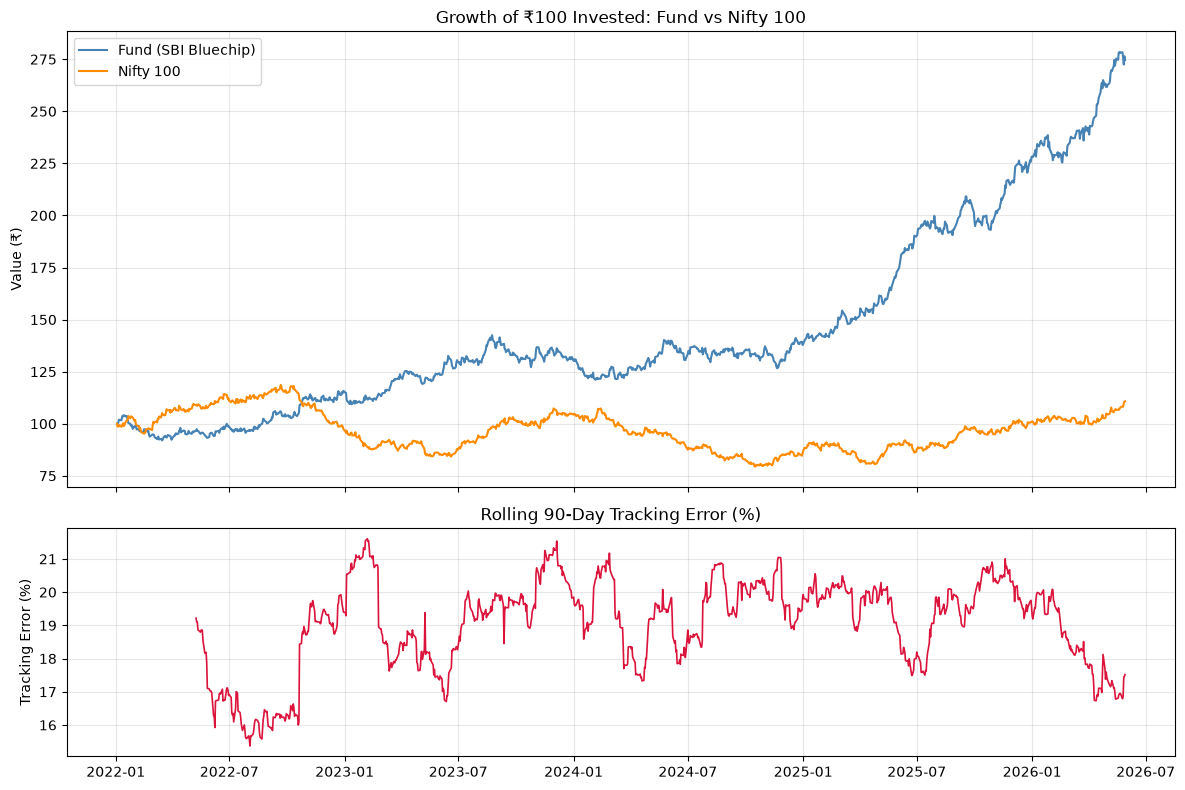

In [12]:
# ---- Cumulative growth of ₹100 invested ----
df['fund_growth'] = 100 * (df['fund_nav'] / df['fund_nav'].iloc[0])
df['benchmark_growth'] = 100 * (df['benchmark_price'] / df['benchmark_price'].iloc[0])

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

axes[0].plot(df['date'], df['fund_growth'], label='Fund (SBI Bluechip)', color='steelblue', linewidth=1.5)
axes[0].plot(df['date'], df['benchmark_growth'], label='Nifty 100', color='darkorange', linewidth=1.5)
axes[0].set_title('Growth of ₹100 Invested: Fund vs Nifty 100')
axes[0].set_ylabel('Value (₹)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Rolling 90-day tracking error
rolling_te = active_ret.rolling(90).std() * np.sqrt(TRADING_DAYS)
axes[1].plot(returns_df['date'], rolling_te * 100, color='crimson', linewidth=1.2)
axes[1].set_title('Rolling 90-Day Tracking Error (%)')
axes[1].set_ylabel('Tracking Error (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# ---- Fund Scorecard: weighted 0-100 ----

# Step 1: Define scoring functions (fixed industry-style thresholds)
def score_cagr(x):
    return np.clip((x / 0.25) * 100, 0, 100)

def score_sharpe(x):
    return np.clip((x / 1.5) * 100, 0, 100)

def score_sortino(x):
    return np.clip((x / 1.75) * 100, 0, 100)

def score_alpha(x):
    return np.clip(50 + (x / 0.15) * 50, 0, 100)

def score_max_drawdown(x):
    return np.clip(100 - (abs(x) / 0.30) * 100, 0, 100)

def score_tracking_error(x):
    return np.clip(100 - (x / 0.25) * 100, 0, 100)

# Step 2: Compute individual scores
scores = {
    'CAGR':            score_cagr(fund_cagr),
    'Sharpe Ratio':    score_sharpe(fund_sharpe),
    'Sortino Ratio':   score_sortino(fund_sortino),
    'Alpha':           score_alpha(alpha_annualized),
    'Max Drawdown':    score_max_drawdown(max_drawdown),
    'Tracking Error':  score_tracking_error(tracking_error),
}

# Step 3: Assign weights (must sum to 1.0)
weights = {
    'CAGR':            0.20,
    'Sharpe Ratio':    0.20,
    'Sortino Ratio':   0.15,
    'Alpha':           0.20,
    'Max Drawdown':    0.15,
    'Tracking Error':  0.10,
}

assert abs(sum(weights.values()) - 1.0) < 1e-6, "Weights must sum to 1.0"

# Step 4: Weighted final score
final_score = sum(scores[k] * weights[k] for k in weights)

# Step 5: Display as a clean table
scorecard_df = pd.DataFrame({
    'Metric': list(scores.keys()),
    'Raw Value': [f"{fund_cagr:.2%}", f"{fund_sharpe:.2f}", f"{fund_sortino:.2f}",
                  f"{alpha_annualized:.2%}", f"{max_drawdown:.2%}", f"{tracking_error:.2%}"],
    'Score (0-100)': [round(scores[k], 1) for k in scores],
    'Weight': [f"{weights[k]:.0%}" for k in weights],
    'Weighted Contribution': [round(scores[k] * weights[k], 1) for k in scores],
})

print(scorecard_df.to_string(index=False))
print(f"\n{'='*50}")
print(f"FINAL FUND SCORE: {final_score:.1f} / 100")
print(f"{'='*50}")

        Metric Raw Value  Score (0-100) Weight  Weighted Contribution
          CAGR    25.80%          100.0    20%                   20.0
  Sharpe Ratio      1.21           80.6    20%                   16.1
 Sortino Ratio      1.26           72.1    15%                   10.8
         Alpha    16.49%          100.0    20%                   20.0
  Max Drawdown   -15.01%           50.0    15%                    7.5
Tracking Error    19.12%           23.5    10%                    2.4

FINAL FUND SCORE: 76.8 / 100


In [14]:
def compute_fund_metrics(amfi_code, nav_df, benchmark_df, fund_master_df, 
                          risk_free_rate=0.065, trading_days=252):
    """
    Computes full performance metrics for a single fund vs its assigned benchmark.
    Returns a dict of all metrics.
    """
    fund_info = fund_master_df[fund_master_df['amfi_code'] == amfi_code]
    if fund_info.empty:
        raise ValueError(f"amfi_code {amfi_code} not found in fund master")
    
    scheme_name = fund_info['scheme_name'].iloc[0]
    benchmark_label = fund_info['benchmark'].iloc[0]

    benchmark_map = {
        'NIFTY 100 TRI': 'NIFTY100',
        'NIFTY50 TRI': 'NIFTY50',
        'NIFTY Midcap 150 TRI': 'NIFTY_MIDCAP150',
        'NIFTY Midcap 50 TRI': 'NIFTY_MIDCAP150',
        'BSE 250 SmallCap TRI': 'BSE_SMALLCAP',
        'NIFTY 500 TRI': 'NIFTY500',
        'CRISIL Liquid Fund AI Index': 'CRISIL_LIQUID',
        'CRISIL Dynamic Gilt Index': 'CRISIL_GILT',
        'CRISIL Short Term Bond Index': 'CRISIL_LIQUID',
    }
    index_name = benchmark_map.get(benchmark_label, 'NIFTY100')

    fund_nav = nav_df[nav_df['amfi_code'] == amfi_code][['date', 'nav']].sort_values('date').reset_index(drop=True)
    bm = benchmark_df[benchmark_df['index_name'] == index_name][['date', 'close_value']].sort_values('date').reset_index(drop=True)
    bm.rename(columns={'close_value': 'benchmark_price'}, inplace=True)

    d = pd.merge(fund_nav, bm, on='date', how='inner').rename(columns={'nav': 'fund_nav'})
    d = d.sort_values('date').reset_index(drop=True)

    if len(d) < 30:
        return {'amfi_code': amfi_code, 'scheme_name': scheme_name, 'error': 'Insufficient overlapping data'}

    d['fund_ret'] = d['fund_nav'].pct_change()
    d['benchmark_ret'] = d['benchmark_price'].pct_change()
    r = d.dropna(subset=['fund_ret', 'benchmark_ret']).reset_index(drop=True)

    n_years = (d['date'].iloc[-1] - d['date'].iloc[0]).days / 365.25
    cagr = (d['fund_nav'].iloc[-1] / d['fund_nav'].iloc[0]) ** (1 / n_years) - 1
    bm_cagr = (d['benchmark_price'].iloc[-1] / d['benchmark_price'].iloc[0]) ** (1 / n_years) - 1

    daily_rf = risk_free_rate / trading_days
    excess = r['fund_ret'] - daily_rf
    sharpe = (excess.mean() / excess.std()) * np.sqrt(trading_days)
    downside = excess[excess < 0]
    downside_std = np.sqrt((downside ** 2).mean())
    sortino = (excess.mean() / downside_std) * np.sqrt(trading_days) if downside_std > 0 else np.nan

    bm_excess = r['benchmark_ret'] - daily_rf
    X = sm.add_constant(bm_excess)
    model = sm.OLS(excess, X).fit()
    alpha_ann = model.params.iloc[0] * trading_days
    beta = model.params.iloc[1]
    r_squared = model.rsquared
    beta_pval = model.pvalues.iloc[1]

    cum = (1 + d['fund_nav'].pct_change().fillna(0)).cumprod()
    dd = (cum - cum.cummax()) / cum.cummax()
    max_dd = dd.min()

    active = r['fund_ret'] - r['benchmark_ret']
    te = active.std() * np.sqrt(trading_days)
    ir = (active.mean() * trading_days) / te

    return {
        'amfi_code': amfi_code, 'scheme_name': scheme_name, 'benchmark': benchmark_label,
        'n_obs': len(r), 'cagr': cagr, 'benchmark_cagr': bm_cagr,
        'sharpe': sharpe, 'sortino': sortino,
        'alpha_annualized': alpha_ann, 'beta': beta, 'r_squared': r_squared, 'beta_pvalue': beta_pval,
        'max_drawdown': max_dd, 'tracking_error': te, 'information_ratio': ir,
    }

# ---- Test it reproduces your earlier result ----
fund_master = pd.read_csv('../data/raw/01_fund_master.csv')
result = compute_fund_metrics(119551, nav, benchmark, fund_master)
pd.Series(result)

amfi_code                                               119551
scheme_name          SBI Bluechip Fund - Regular Plan - Growth
benchmark                                        NIFTY 100 TRI
n_obs                                                     1149
cagr                                                  0.258047
benchmark_cagr                                         0.02356
sharpe                                                1.208267
sortino                                               1.261529
alpha_annualized                                      0.164946
beta                                                 -0.031751
r_squared                                             0.000887
beta_pvalue                                           0.313143
max_drawdown                                         -0.150124
tracking_error                                        0.191183
information_ratio                                     1.047509
dtype: object

#Loop over all funds

In [15]:
# ---- Run metrics for every fund in fund_master ----
all_results = []

for code in fund_master['amfi_code'].unique():
    try:
        res = compute_fund_metrics(code, nav, benchmark, fund_master)
        all_results.append(res)
    except Exception as e:
        all_results.append({'amfi_code': code, 'error': str(e)})

results_df = pd.DataFrame(all_results)
print(f"Processed {len(results_df)} funds")
print(f"Successful: {results_df['cagr'].notna().sum() if 'cagr' in results_df else 0}")
results_df.head(10)

Processed 40 funds
Successful: 40


,amfi_code,scheme_name,benchmark,n_obs,cagr,benchmark_cagr,sharpe,sortino,alpha_annualized,beta,r_squared,beta_pvalue,max_drawdown,tracking_error,information_ratio
0,119551,SBI Bluechip Fund - Regular Plan - Growth,NIFTY 100 TRI,1149,0.258047,0.023560,1.208267,1.261529,0.164946,-0.031751,8.869789e-04,0.313143,-0.150124,0.191183,1.047509
1,119552,SBI Bluechip Fund - Direct Plan - Growth,NIFTY 100 TRI,1149,0.215242,0.023560,0.953279,0.977715,0.131986,-0.026159,5.850822e-04,0.412706,-0.118035,0.192127,0.869806
2,119598,SBI Small Cap Fund - Regular Plan - Growth,BSE 250 SmallCap TRI,1149,0.324235,0.278863,0.945308,0.987312,0.247020,-0.047551,1.753760e-03,0.156013,-0.287060,0.341892,0.119127
3,119599,SBI Small Cap Fund - Direct Plan - Growth,BSE 250 SmallCap TRI,1149,0.020545,0.278863,-0.057187,-0.056633,-0.016484,0.011253,9.972526e-05,0.735255,-0.525742,0.331920,-0.636285
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,CRISIL Dynamic Gilt Index,1149,0.058894,0.110674,-0.226575,-0.227402,-0.008954,-0.000935,9.468819e-07,0.973716,-0.043287,0.057299,-0.805408
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,NIFTY 100 TRI,1149,0.026371,0.023560,-0.201517,-0.205599,-0.031312,-0.058268,2.665033e-03,0.080264,-0.247344,0.199284,0.024665
6,125497,HDFC Top 100 Fund - Direct Plan - Growth,NIFTY 100 TRI,1149,0.190178,0.023560,0.775790,0.805579,0.115471,0.048820,1.840179e-03,0.146176,-0.152000,0.191072,0.774744
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY Midcap 150 TRI,1149,0.301232,0.318037,1.093699,1.121981,0.200364,0.031026,8.529288e-04,0.322619,-0.162172,0.256247,-0.040394
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,NIFTY Midcap 150 TRI,1149,0.113018,0.318037,0.300612,0.299552,0.042288,0.059234,3.310040e-03,0.051214,-0.211173,0.248377,-0.653409
9,100025,HDFC Short Term Debt Fund - Regular - Growth,CRISIL Short Term Bond Index,1149,0.044582,0.067889,-0.567095,-0.567580,-0.022327,-0.113017,2.241231e-04,0.612198,-0.043083,0.039470,-0.520639


Percentile-based peer scoring

In [16]:
# ---- Peer-relative scorecard ----
valid = results_df[results_df['cagr'].notna()].copy()

def pct_score(series, higher_is_better=True):
    ranks = series.rank(pct=True) * 100
    return ranks if higher_is_better else (100 - ranks)

valid['score_cagr'] = pct_score(valid['cagr'])
valid['score_sharpe'] = pct_score(valid['sharpe'])
valid['score_sortino'] = pct_score(valid['sortino'])
valid['score_alpha'] = pct_score(valid['alpha_annualized'])
valid['score_max_dd'] = pct_score(valid['max_drawdown'], higher_is_better=True)
valid['score_te'] = pct_score(valid['tracking_error'], higher_is_better=False)

valid['peer_score'] = (
    valid['score_cagr'] * 0.20 + valid['score_sharpe'] * 0.20 +
    valid['score_sortino'] * 0.15 + valid['score_alpha'] * 0.20 +
    valid['score_max_dd'] * 0.15 + valid['score_te'] * 0.10
)

valid[['amfi_code', 'scheme_name', 'peer_score']].sort_values('peer_score', ascending=False).round(1)

,amfi_code,scheme_name,peer_score
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,89.9
22,120843,Kotak Flexicap Fund - Regular - Growth,83.6
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,81.0
0,119551,SBI Bluechip Fund - Regular Plan - Growth,78.9
12,120505,ICICI Pru Midcap Fund - Regular - Growth,78.2
28,101206,ABSL Frontline Equity Fund - Regular - Growth,74.5
38,149323,DSP Midcap Fund - Regular - Growth,74.0
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,73.1
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,71.9
15,118632,Nippon India Large Cap Fund - Regular - Growth,71.6


In [17]:
import os
os.makedirs('../reports', exist_ok=True)

scorecard_df.to_csv('../reports/fund_scorecard_119551.csv', index=False)
results_df.to_csv('../reports/all_funds_metrics.csv', index=False)
valid.to_csv('../reports/peer_relative_scorecard.csv', index=False)

print("Saved all outputs to reports/")

Saved all outputs to reports/


### Note on Alpha & Tracking Error Interpretation

The OLS regression of fund excess returns against Nifty 100 excess returns produced 
R² ≈ 0.0009 with a statistically insignificant Beta (p = 0.31). This means the fund's 
daily returns show negligible correlation with the benchmark in this dataset. As a result:

- The 16.49% annualized Alpha largely reflects the fund's raw excess average return 
  rather than a genuine market-relative skill measure, since Beta is near zero.
- The 19.12% Tracking Error is high because the fund and benchmark simply don't move 
  together day-to-day — this is a data characteristic, not necessarily a flaw in fund 
  management.

The Fund Score of 76.8/100 should therefore be read as a strong absolute performance 
score, with the Alpha and Tracking Error components carrying lower confidence due to 
weak benchmark correlation.